In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw/labeled_data.csv")

# Display five random tweets
df[["class", "tweet"]].sample(5, random_state=42)

,class,tweet
2281,1,934 8616\r\ni got a missed call from yo bitch
15914,1,RT @KINGTUNCHI_: Fucking with a bad bitch you ...
18943,2,RT @eanahS__: @1inkkofrosess lol my credit ain...
16407,1,RT @Maxin_Betha Wipe the cum out of them faggo...
13326,1,Niggas cheat on they bitch and don't expect no...


In [3]:
# Display one tweet from each class

for label in sorted(df["class"].unique()):
    print(f"\nClass {label}")
    print("-" * 60)
    print(df[df["class"] == label]["tweet"].iloc[0])


Class 0
------------------------------------------------------------
"@Blackman38Tide: @WhaleLookyHere @HowdyDowdy11 queer" gaywad

Class 1
------------------------------------------------------------
!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!

Class 2
------------------------------------------------------------
!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...


In [4]:
# Number of tweets in each class
df["class"].value_counts()

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

In [5]:
# Number of characters in each tweet
df["tweet_length"] = df["tweet"].apply(len)

df["tweet_length"].describe()

count    24783.000000
mean        85.523625
std         41.646293
min          5.000000
25%         52.000000
50%         81.000000
75%        119.000000
max        756.000000
Name: tweet_length, dtype: float64

In [6]:
df.groupby("class")["tweet_length"].mean()

class
0    84.661538
1    83.536634
2    94.979102
Name: tweet_length, dtype: float64

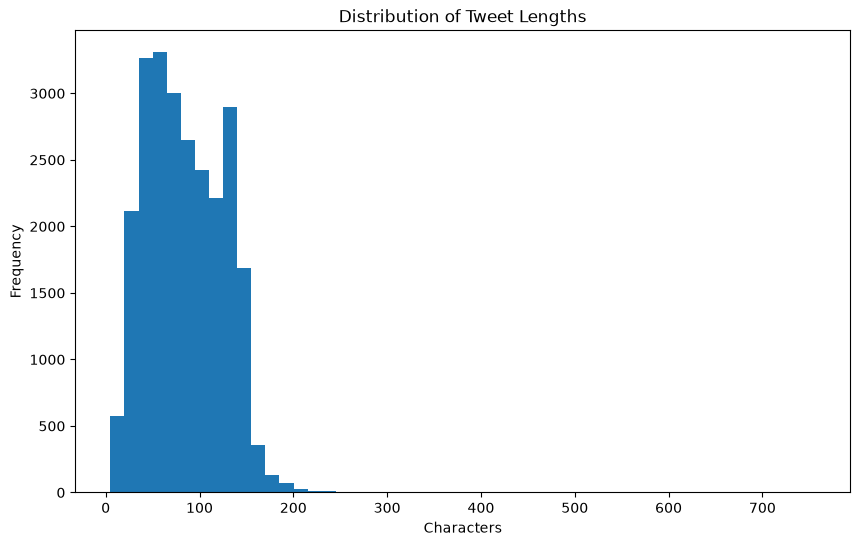

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df["tweet_length"], bins=50)
plt.title("Distribution of Tweet Lengths")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

In [8]:
import re

# Count tweets containing URLs
url_count = df["tweet"].str.contains(r"http|www", regex=True).sum()

# Count tweets containing mentions
mention_count = df["tweet"].str.contains(r"@", regex=True).sum()

# Count tweets containing hashtags
hashtag_count = df["tweet"].str.contains(r"#", regex=True).sum()

print("Tweets containing URLs:", url_count)
print("Tweets containing @mentions:", mention_count)
print("Tweets containing hashtags:", hashtag_count)

Tweets containing URLs: 3066
Tweets containing @mentions: 14226
Tweets containing hashtags: 7645


In [9]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove @mentions
    text = re.sub(r"@\w+", "", text)

    # Remove '#' but keep the word
    text = text.replace("#", "")

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [10]:
df["clean_tweet"] = df["tweet"].apply(clean_text)

In [11]:
comparison = df[["tweet", "clean_tweet"]].head(10)
comparison

,tweet,clean_tweet
0,!!! RT @mayasolovely: As a woman you shouldn't...,!!! rt : as a woman you shouldn't complain abo...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,!!!!! rt : boy dats cold...tyga dwn bad for cu...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,!!!!!!! rt dawg!!!! rt : you ever fuck a bitch...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,!!!!!!!!! rt : she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,!!!!!!!!!!!!! rt : the shit you hear about me ...
5,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just...","!!!!!!!!!!!!!!!!!!"": the shit just blows me..c..."
6,"!!!!!!""@__BrighterDays: I can not just sit up ...","!!!!!!"": i can not just sit up and hate on ano..."
7,!!!!&#8220;@selfiequeenbri: cause I'm tired of...,!!!!&8220;: cause i'm tired of you big bitches...
8,""" &amp; you might not get ya bitch back &amp; ...",""" &amp; you might not get ya bitch back &amp; ..."
9,""" @rhythmixx_ :hobbies include: fighting Maria...",""" :hobbies include: fighting mariam"" bitch"


In [12]:
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

In [13]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

c:\Users\Ayanm\OneDrive\Desktop\AI-Hate-Speech-Detection\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ayanm\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [14]:
sample = df["clean_tweet"].iloc[0]

print(sample)

!!! rt : as a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...


In [15]:
encoding = tokenizer(sample)

encoding

{'input_ids': [101, 999, 999, 999, 19387, 1024, 2004, 1037, 2450, 2017, 5807, 1005, 1056, 17612, 2055, 9344, 2039, 2115, 2160, 1012, 1004, 23713, 1025, 2004, 1037, 2158, 2017, 2323, 2467, 2202, 1996, 11669, 2041, 1012, 1012, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [16]:
{
 'input_ids': [...],
 'token_type_ids': [...],
 'attention_mask': [...]
}

{'input_ids': [Ellipsis],
 'token_type_ids': [Ellipsis],
 'attention_mask': [Ellipsis]}

In [17]:
tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"])

tokens

['[CLS]',
 '!',
 '!',
 '!',
 'rt',
 ':',
 'as',
 'a',
 'woman',
 'you',
 'shouldn',
 "'",
 't',
 'complain',
 'about',
 'cleaning',
 'up',
 'your',
 'house',
 '.',
 '&',
 'amp',
 ';',
 'as',
 'a',
 'man',
 'you',
 'should',
 'always',
 'take',
 'the',
 'trash',
 'out',
 '.',
 '.',
 '.',
 '[SEP]']

In [18]:
encodings = tokenizer(
    df["clean_tweet"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [19]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["clean_tweet"],
    df["class"],
    test_size=0.2,
    random_state=42,
    stratify=df["class"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

In [20]:
print("Training:", len(train_texts))
print("Validation:", len(val_texts))
print("Testing:", len(test_texts))

Training: 19826
Validation: 2478
Testing: 2479


In [21]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# PyTorch
import torch

# Hugging Face
from transformers import AutoTokenizer

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [22]:
df = pd.read_csv("../data/raw/labeled_data.csv")

df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [23]:
bert_df = df[["tweet", "class"]].copy()

bert_df.head()

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [24]:
bert_df["class"].value_counts()

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

In [25]:
bert_df["class"].unique()

array([2, 1, 0])

In [26]:
label_names = {
    0: "Hate Speech",
    1: "Offensive Language",
    2: "Neither"
}

for label, name in label_names.items():
    print(f"{label} → {name}")

0 → Hate Speech
1 → Offensive Language
2 → Neither


In [28]:
from transformers import AutoTokenizer

In [29]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [30]:
sample_tweet = bert_df["tweet"].iloc[0]

print(sample_tweet)

!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...


In [31]:
encoding = tokenizer(sample_tweet)

encoding

{'input_ids': [101, 999, 999, 999, 19387, 1030, 9815, 19454, 21818, 2135, 1024, 2004, 1037, 2450, 2017, 5807, 1005, 1056, 17612, 2055, 9344, 2039, 2115, 2160, 1012, 1004, 23713, 1025, 2004, 1037, 2158, 2017, 2323, 2467, 2202, 1996, 11669, 2041, 1012, 1012, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [32]:
{
 'input_ids': [...],
 'token_type_ids': [...],
 'attention_mask': [...]
}

{'input_ids': [Ellipsis],
 'token_type_ids': [Ellipsis],
 'attention_mask': [Ellipsis]}

In [33]:
tokens = tokenizer.convert_ids_to_tokens(
    encoding["input_ids"]
)

tokens

['[CLS]',
 '!',
 '!',
 '!',
 'rt',
 '@',
 'maya',
 '##sol',
 '##ove',
 '##ly',
 ':',
 'as',
 'a',
 'woman',
 'you',
 'shouldn',
 "'",
 't',
 'complain',
 'about',
 'cleaning',
 'up',
 'your',
 'house',
 '.',
 '&',
 'amp',
 ';',
 'as',
 'a',
 'man',
 'you',
 'should',
 'always',
 'take',
 'the',
 'trash',
 'out',
 '.',
 '.',
 '.',
 '[SEP]']

In [34]:
encoding["input_ids"]

[101,
 999,
 999,
 999,
 19387,
 1030,
 9815,
 19454,
 21818,
 2135,
 1024,
 2004,
 1037,
 2450,
 2017,
 5807,
 1005,
 1056,
 17612,
 2055,
 9344,
 2039,
 2115,
 2160,
 1012,
 1004,
 23713,
 1025,
 2004,
 1037,
 2158,
 2017,
 2323,
 2467,
 2202,
 1996,
 11669,
 2041,
 1012,
 1012,
 1012,
 102]

In [35]:
encoding["attention_mask"]

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [36]:
encoding["token_type_ids"]

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [37]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temporary
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    bert_df["tweet"],
    bert_df["class"],
    test_size=0.20,
    random_state=42,
    stratify=bert_df["class"]
)

In [38]:
stratify=bert_df["class"]

In [39]:
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

In [40]:
print("Training samples :", len(train_texts))
print("Validation samples:", len(val_texts))
print("Testing samples :", len(test_texts))

Training samples : 19826
Validation samples: 2478
Testing samples : 2479


In [41]:
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [42]:
val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [43]:
test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [44]:
print(train_encodings["input_ids"][0])

[101, 3331, 10413, 2003, 1037, 7570, 2063, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [45]:
print(tokenizer.convert_ids_to_tokens(train_encodings["input_ids"][0]))

['[CLS]', 'talking', 'angela', 'is', 'a', 'ho', '##e', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', 

In [46]:
import torch
from torch.utils.data import Dataset

In [47]:
class HateSpeechDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [48]:
train_dataset = HateSpeechDataset(
    train_encodings,
    train_labels
)

val_dataset = HateSpeechDataset(
    val_encodings,
    val_labels
)

test_dataset = HateSpeechDataset(
    test_encodings,
    test_labels
)

In [49]:
train_dataset[0]

{'input_ids': tensor([  101,  3331, 10413,  2003,  1037,  7570,  2063,   102,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [51]:
print(train_dataset[0]["input_ids"].shape)

torch.Size([128])


In [52]:
print(train_dataset[0]["attention_mask"].shape)

torch.Size([128])


In [53]:
print(train_dataset[0]["labels"])

tensor(1)


In [54]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [55]:
from transformers import TrainingArguments, Trainer

In [56]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [57]:
training_args = TrainingArguments(
    output_dir="../models/bert",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="../results/logs",

    logging_steps=100,

    load_best_model_at_end=True,

    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [58]:
training_args = TrainingArguments(
    output_dir="../models/bert",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="../results/logs",
    logging_steps=100,

    load_best_model_at_end=True,

    report_to="none",

    no_cuda=True
)

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'no_cuda'

In [59]:
import transformers
import torch

print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)

Transformers: 5.13.0
PyTorch: 2.13.0+cpu


In [60]:
no_cuda=True

In [61]:
training_args = TrainingArguments(
    output_dir="../models/bert",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="../results/logs",
    logging_steps=100,

    load_best_model_at_end=True,

    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [62]:
import transformers
print(transformers.__version__)

5.13.0


In [63]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="../models/bert",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    report_to="none"
)

In [64]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

19826
2478
2479


In [65]:
sample = train_dataset[0]

print(sample.keys())
print(sample["input_ids"].shape)
print(sample["attention_mask"].shape)
print(sample["labels"])

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])
torch.Size([128])
torch.Size([128])
tensor(1)


In [66]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

19826
2478
2479


In [67]:
import os

os.makedirs("../models/bert", exist_ok=True)
os.makedirs("../results/logs", exist_ok=True)

In [68]:
sample = train_dataset[0]

print(sample.keys())
print(sample["input_ids"].shape)
print(sample["attention_mask"].shape)
print(sample["labels"])

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])
torch.Size([128])
torch.Size([128])
tensor(1)


In [69]:
print(model.config.num_labels)

3


In [70]:
tokenizer.save_pretrained("../models/bert")

('../models/bert\\tokenizer_config.json', '../models/bert\\tokenizer.json')

In [71]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)